# GeoZarr pyramid demo

Convert a slice of the OceanSODA-ETHZ-HR delta-fCO2 product (global, 0.25 degrees, Zarr v3) into a GeoZarr multiscale pyramid, validate it and look at two levels.

In [ ]:
import matplotlib.pyplot as plt
import xarray as xr
from dask.diagnostics.progress import ProgressBar

import geozarr_pyramid_maker as gpm

In [2]:
gpm.configure_logging("INFO")

## Open the data

The full store has 1886 weekly steps. We take only the first 12 (about 47 MiB) so the demo runs in seconds. The source has no CRS information, so EPSG:4326 is inferred (with a warning) and the ascending latitude axis is flipped north-up (also with a warning).

In [51]:
URL = "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/ocean-soda/dfco2.zarr/"
ds = xr.open_zarr(URL).isel(time=slice(0, 12)).sel(lat=slice(-30, 30), lon=slice(-180, -80)).isel(time=0)
ds

<xarray.Dataset> Size: 389kB
Dimensions:  (lat: 240, lon: 400)
Coordinates:
  * lat      (lat) float64 2kB -29.88 -29.62 -29.38 -29.12 ... 29.38 29.62 29.88
  * lon      (lon) float64 3kB -179.9 -179.6 -179.4 ... -80.62 -80.38 -80.12
    time     datetime64[ns] 8B 1982-01-04
Data variables:
    dfco2    (lat, lon) float32 384kB dask.array<chunksize=(240, 400), meta=np.ndarray>
Attributes: (12/14)
    contact:                   gregorl@ethz.ch
    affiliation:               ETH Zuerich
    product_name:              OceanSODA-ETHZ-HR
    product_version:           v2023.01
    project:                   ESA-OceanHealth-OceanAcidification
    product_details:           Fugacity of CO2 (fCO2) and total alkalinity ar...
    ...                        ...
    geospatial_min_latitude:   -89.875
    geospatial_max_latitude:   89.875
    geospatial_min_longitude:  -179.875
    geospatial_max_longitude:  179.875
    time_coverage_start:       1982-01-01T00:00:00
    time_coverage_end:         1982-01-08T23:59:59

In [52]:
plan = ds.geozarr.plan()
print(plan)

2026-10-01 09:09:33.205 | WARNING  | geozarr_pyramid_maker.detect:_resolve_crs:158 - No CRS found; inferred EPSG:4326 from lon/lat coordinates (pass crs= to override)
2026-10-01 09:09:33.208 | WARNING  | geozarr_pyramid_maker.detect:detect:384 - 'lat' is ascending; flipped to descending (north-up)
2026-10-01 09:09:33.213 | INFO     | geozarr_pyramid_maker.detect:detect:450 - Detected grid: crs=EPSG:4326, dims=(lat, lon), shape=(240, 400), variables=['dfco2']


PyramidPlan: 1 level(s), CRS EPSG:4326
  dims: (lat, lon)   extra dims: none
  tile: 512 px   shard target: 128 MiB
  variables:
    dfco2: mean, float32

  level  shape    resolution  variable  chunks   shards  size
  -----  -------  ----------  --------  -------  ------  -------
  0      240×400  0.25, 0.25  dfco2     240×400  -       375 KiB

  total uncompressed: 375 KiB


In [53]:
result = ds.geozarr.to_pyramid("oceansoda_dfco2.zarr", overwrite=True)
print(f"total: {result.timings['total']:.1f} s")

2026-10-01 09:09:36.474 | WARNING  | geozarr_pyramid_maker.detect:_resolve_crs:158 - No CRS found; inferred EPSG:4326 from lon/lat coordinates (pass crs= to override)
2026-10-01 09:09:36.475 | WARNING  | geozarr_pyramid_maker.detect:detect:384 - 'lat' is ascending; flipped to descending (north-up)
2026-10-01 09:09:36.476 | INFO     | geozarr_pyramid_maker.detect:detect:450 - Detected grid: crs=EPSG:4326, dims=(lat, lon), shape=(240, 400), variables=['dfco2']
2026-10-01 09:09:36.477 | INFO     | geozarr_pyramid_maker.write:to_pyramid:246 - Pyramid plan: 1 level(s), 375.0 KiB uncompressed in total
2026-10-01 09:09:36.488 | WARNING  | geozarr_pyramid_maker.write:to_pyramid:259 - Overwriting existing zarr data in oceansoda_dfco2.zarr
2026-10-01 09:09:37.450 | INFO     | geozarr_pyramid_maker.write:to_pyramid:272 - Level 0 written: shape=(240, 400) in 1.0 s (375.0 KiB uncompressed)
2026-10-01 09:09:37.469 | INFO     | geozarr_pyramid_maker.validate:validate:209 - Validation passed
2026-10-0

total: 1.0 s


In [49]:
print(result.validation)
gpm.is_valid(result.validation)

{'zarr_conventions': [], 'multiscales': [], 'spatial': [], 'proj': [], 'structure': []}


True

In [50]:
tree = xr.open_datatree("oceansoda_dfco2.zarr", engine="zarr")
for name, node in tree.children.items():
    print(name, dict(node.ds.sizes), node.ds["dfco2"].encoding.get("shards"))

0 {'lat': 720, 'lon': 1440} (1024, 1536)
1 {'lat': 360, 'lon': 720} None
2 {'lat': 180, 'lon': 360} None


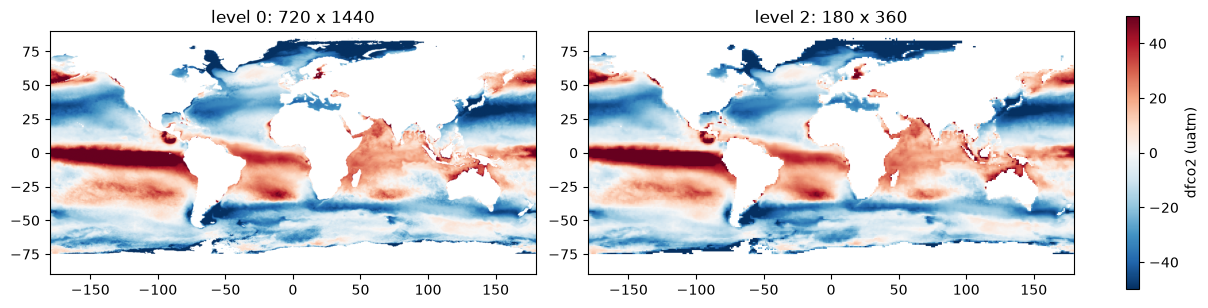

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), constrained_layout=True)
for ax, name in zip(axes, ("0", str(len(plan.levels) - 1)), strict=True):
    da = tree[name].ds["dfco2"].isel(time=0)
    x, y = da[da.dims[-1]].values, da[da.dims[-2]].values
    dx, dy = abs(x[1] - x[0]), abs(y[1] - y[0])
    extent = (x[0] - dx / 2, x[-1] + dx / 2, y[-1] - dy / 2, y[0] + dy / 2)
    im = ax.imshow(da.values, extent=extent, cmap="RdBu_r", vmin=-50, vmax=50)
    ax.set_title(f"level {name}: {da.shape[0]} x {da.shape[1]}")
fig.colorbar(im, ax=axes, label="dfco2 (uatm)", shrink=0.8)
plt.show()

## Preview in the browser

Run this in a terminal (the server blocks, so it is not a notebook cell):

```bash
geozarr-pyramid preview oceansoda_dfco2.zarr --serve
```

In [43]:
# MUR SST Example

In [ ]:
ds = xr.open_zarr(
    "s3://mur-sst/zarr-v1/",
    storage_options={"client_kwargs": {"region_name": "us-west-2"}, "anon": True},
    consolidated=True,
)

ds_subset = ds[['analysed_sst']].isel(time=slice(5000, 5010)).astype('float32')

In [42]:
ds_subset.geozarr.plan()

2026-10-01 09:01:15.063 | WARNING  | geozarr_pyramid_maker.detect:_resolve_crs:158 - No CRS found; inferred EPSG:4326 from lon/lat coordinates (pass crs= to override)


2026-10-01 09:01:15.070 | WARNING  | geozarr_pyramid_maker.detect:detect:384 - 'lat' is ascending; flipped to descending (north-up)
2026-10-01 09:01:15.080 | INFO     | geozarr_pyramid_maker.detect:detect:450 - Detected grid: crs=EPSG:4326, dims=(lat, lon), shape=(17999, 36000), variables=['analysed_sst']


PyramidPlan: 8 level(s), CRS EPSG:4326
  dims: (lat, lon)   extra dims: time=10
  tile: 512 px   shard target: 128 MiB
  variables:
    analysed_sst: mean, float32

  level  shape        resolution  variable      chunks     shards        size
  -----  -----------  ----------  ------------  ---------  ------------  ---------
  0      17999×36000  0.01, 0.01  analysed_sst  1×512²     1×4096²       24.1 GiB
  1      9000×18000   0.02, 0.02  analysed_sst  1×512²     1×4096²       6 GiB
  2      4500×9000    0.04, 0.04  analysed_sst  1×512²     1×4096²       1.5 GiB
  3      2250×4500    0.08, 0.08  analysed_sst  1×512²     1×2560×4096   386.2 MiB
  4      1125×2250    0.16, 0.16  analysed_sst  1×512²     8×1536×2560   96.6 MiB
  5      563×1125     0.32, 0.32  analysed_sst  1×512²     10×1024×1536  24.2 MiB
  6      282×563      0.64, 0.64  analysed_sst  1×282×512  10×282×1024   6.1 MiB
  7      141×282      1.28, 1.28  analysed_sst  1×141×282  10×141×282    1.5 MiB

  total uncompressed: 

In [ ]:
with ProgressBar():
    ds_subset.geozarr.to_pyramid("mur_sst_subset.zarr", overwrite=True)

2026-10-01 08:50:19.321 | WARNING  | geozarr_pyramid_maker.detect:_resolve_crs:158 - No CRS found; inferred EPSG:4326 from lon/lat coordinates (pass crs= to override)
2026-10-01 08:50:19.322 | WARNING  | geozarr_pyramid_maker.detect:detect:384 - 'lat' is ascending; flipped to descending (north-up)
2026-10-01 08:50:19.328 | INFO     | geozarr_pyramid_maker.detect:detect:450 - Detected grid: crs=EPSG:4326, dims=(lat, lon), shape=(17999, 36000), variables=['analysed_sst']
2026-10-01 08:50:19.329 | INFO     | geozarr_pyramid_maker.write:to_pyramid:246 - Pyramid plan: 8 level(s), 32.2 GiB uncompressed in total
2026-10-01 08:50:19.339 | WARNING  | geozarr_pyramid_maker.write:to_pyramid:259 - Overwriting existing zarr data in mur_sst_subset.zarr


[########################################] | 100% Completed | 326.06 s


2026-10-01 08:55:45.935 | INFO     | geozarr_pyramid_maker.write:to_pyramid:272 - Level 0 written: shape=(17999, 36000) in 326.3 s (24.1 GiB uncompressed)


[########################################] | 100% Completed | 28.42 ss


2026-10-01 08:56:14.556 | INFO     | geozarr_pyramid_maker.write:to_pyramid:305 - Level 1 written: shape=(9000, 18000) in 28.6 s (6.0 GiB uncompressed)


...

2026-10-01 08:56:25.835 | INFO     | geozarr_pyramid_maker.write:to_pyramid:305 - Level 5 written: shape=(563, 1125) in 0.4 s (24.2 MiB uncompressed)


[########################################] | 100% Completed | 104.94 ms


2026-10-01 08:56:25.975 | INFO     | geozarr_pyramid_maker.write:to_pyramid:305 - Level 6 written: shape=(282, 563) in 0.1 s (6.1 MiB uncompressed)


[########################################] | 100% Completed | 105.66 ms


2026-10-01 08:56:26.158 | INFO     | geozarr_pyramid_maker.write:to_pyramid:305 - Level 7 written: shape=(141, 282) in 0.2 s (1.5 MiB uncompressed)
2026-10-01 08:56:26.249 | INFO     | geozarr_pyramid_maker.validate:validate:209 - Validation passed
2026-10-01 08:56:26.250 | INFO     | geozarr_pyramid_maker.write:to_pyramid:341 - Pyramid written to mur_sst_subset.zarr in 366.9 s
